In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression, Ridge
from matplotlib.collections import EllipseCollection
from matplotlib.colors import Normalize
from sklearn.metrics import auc
from sklearn.feature_extraction import DictVectorizer



from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif




In [2]:
data = 'data/bank-full.csv'
df = pd.read_csv(data, delimiter=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [3]:
features = df.drop('y', axis=1)

education = df['education']

most_frequent_education = education.mode()[0]
most_frequent_education

categorials_columns = list(df.dtypes[df.dtypes == 'object'].index)
categorials_columns

le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

X = df.drop(columns=['y'])
y = df['y']

In [4]:

# Making numerical variables binary
avg_price = df['y'].mean()
above_avg = df['y'] > avg_price

# Binary variables: if above average
#1: True
#0: False
df['y'] = above_avg.astype(int)

display(df[['y']].head())
print('Average:', round(avg_price, 0))

,y
0,0
1,0
2,0
3,0
4,0


Average: 0.0


In [5]:
# Split data : 100% -> 1*(1 - 0.2) = 0.8/ 1*0.2 = 0.2
df_full_train, df_test = train_test_split(df, test_size = 0.2,  random_state=1)
# Split again : 80% -> 0.8(1 - 0.25) = 0.6/ 0.8*0.25 = 0.2 
df_train, df_val = train_test_split(df_full_train, test_size = 0.25,  random_state=1)

# save target values
Y_train = df_train['y'].values
Y_val = df_val['y'].values

# take out the target values from the dataframe
del df_train['y']
del df_val['y']

In [6]:
def roc_prec_recall(feature, target, thresholds = None, feature_selection = True):

    feature = np.array(feature)
    target = np.array(target)

    # Mergesort is a stable sort, 
    # The order of equal elements will not change after sorting.
    sorted_indices = np.argsort(feature, kind="mergesort")[::-1]
    feature_sorted = feature[sorted_indices]
    target_sorted = target[sorted_indices]
    if thresholds is None:
        thresholds = np.unique(feature_sorted)

    
    tpr_list = [0]
    fpr_list = [0]
    precision_list = []
    recall_list = []
    # Predicted positives and negatives based on current threshold
    for threshold in thresholds:

        # Predict classes
        predicted_pos = feature >= threshold
        predicted_neg = feature < threshold

        # True classes
        true_pos = target == 1
        true_neg = target == 0


        tp = (true_pos & predicted_pos).sum()
        tn = (true_neg & predicted_neg).sum()
        fp = (predicted_pos & true_neg).sum()
        fn = (predicted_neg & true_pos).sum()


        tpr = tp/(fn + tp )
        fpr = fp/(fp + tn ) 
        precision = tp/(tp+fp)
        recall = tp/(tp + fn) 

        tpr_list.append(tpr)
        fpr_list.append(fpr)
        precision_list.append(precision)
        recall_list.append(recall)

    tpr = sorted(tpr_list)
    fpr = sorted(fpr_list)
    precision = precision_list
    recall = recall_list

    AUC = auc(fpr, tpr)

    if AUC <= 0.5 and feature_selection:
        feature = -feature
        return roc_prec_recall(feature, target) 
    
    return AUC, fpr, tpr, precision, recall

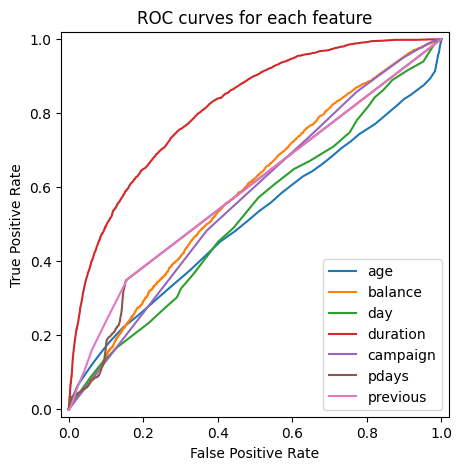

,Feature,AUC
3,duration,0.81
6,previous,0.60
1,balance,0.59
5,pdays,0.59
4,campaign,0.57
2,day,0.53
0,age,0.51


In [7]:
# Numerical features
mask = df.dtypes != object
numerical = list(df_train.dtypes[mask].index)


plt.figure(figsize=(5, 5))

# For each numerical feature, compute its importance and plot its ROC curve.
auc_dic = {}
for feature in numerical:
    current_auc, fpr, tpr, _, _ = roc_prec_recall(df_train[feature], Y_train)
    auc_dic[feature] = round(current_auc,2)
    plt.plot(fpr, tpr, label=f'{feature}')

# Setting the plot legend, limits, labels, and title.
plt.legend()
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for each feature')

plt.show()

# Convert the dictionary to a DataFrame
auc_df = pd.DataFrame(list(auc_dic.items()), columns=['Feature', 'AUC'])\
                                .sort_values(by='AUC', ascending=False)

display(auc_df)


In [8]:
train_dict = df_train.to_dict(orient = 'records')
val_dict = df_val.to_dict(orient = 'records')

# One-Hot encode
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)

model = LogisticRegression(solver='liblinear',C = 1.0, max_iter=1000)
model.fit(X_train, Y_train)

# get predicted probabilities for the positive class
Y_pred_proba = model.predict_proba(X_val)[:, 1]

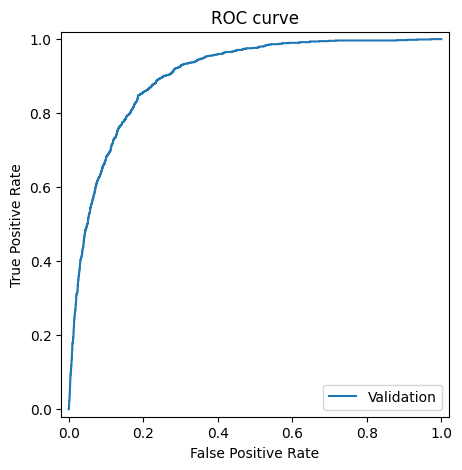

AUC = 0.901


In [9]:
plt.figure(figsize=(5, 5))
auc_value, fpr,tpr, __,_ = roc_prec_recall(Y_pred_proba, Y_val, feature_selection=False)
plt.plot(fpr, tpr, label=f'Validation')

# Settings
plt.legend()
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')

plt.show()

print('AUC =', round(auc_value, 3) )

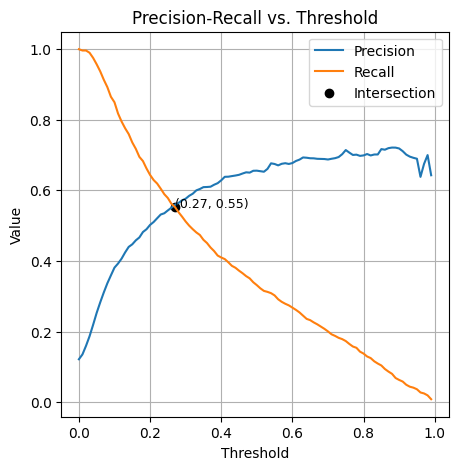

In [10]:
# Compute precision and recall using your function
thresholds = np.arange(0.0, 1.0 ,0.01)
_, _,_, precision, recall = roc_prec_recall(Y_pred_proba, Y_val, thresholds, feature_selection = False)

# Intersection point between precision and recall
intersect_point = np.abs(np.array(precision) - np.array(recall))
idx = np.argmin(intersect_point)
intersect_threshold =  thresholds[idx]
intersect_recall = recall[idx]

plt.figure(figsize=(5, 5))
_, _,_, precision, recall = roc_prec_recall(Y_pred_proba, Y_val, thresholds, feature_selection = False)
plt.plot(thresholds, precision, label=f'Precision')
plt.plot(thresholds, recall, label=f'Recall')
plt.scatter(intersect_threshold,intersect_recall, color = 'black', label='Intersection')
plt.text(   intersect_threshold, intersect_recall, 
            f'({intersect_threshold:.2f}, {intersect_recall:.2f})', color = 'black', fontsize=9)

# Settings
plt.legend()
plt.xlabel('Threshold')
plt.ylabel('Value')
plt.title('Precision-Recall vs. Threshold')
plt.grid(True)
plt.show()


In [11]:
# Compute precision and recall using your function
thresholds = np.arange(0.0, 1.0, 0.01)
_, _, _, precision, recall = roc_prec_recall(   Y_pred_proba, Y_val, 
                                                thresholds, feature_selection=False)

# Compute F1 scores
precision = np.array(precision)
recall = np.array(recall)
F1 = 2 * (precision * recall) / (precision + recall)


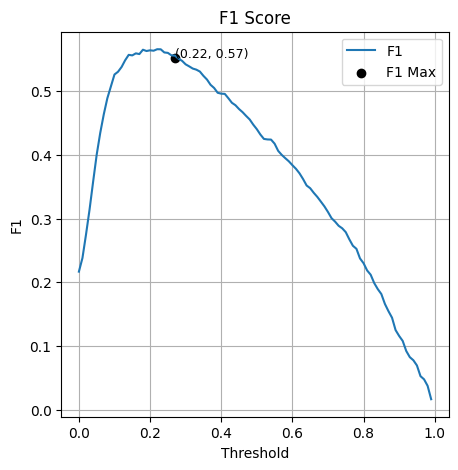

In [12]:
# Compute precision and recall using your function
thresholds = np.arange(0.0, 1.0, 0.01)
_, _, _, precision, recall = roc_prec_recall(   Y_pred_proba, Y_val, 
                                                thresholds, feature_selection=False)

# Compute F1 scores
precision = np.array(precision)
recall = np.array(recall)
F1 = 2 * (precision * recall) / (precision + recall)

# F1 maximum
idx = np.argmax(F1)
max_threshold = thresholds[idx]
max_f1 = F1[idx]

plt.figure(figsize=(5, 5))
plt.plot(thresholds, F1, label=f'F1')
plt.scatter(intersect_threshold,intersect_recall, color = 'black', label='F1 Max')
plt.text(   intersect_threshold, intersect_recall, 
            f'({max_threshold:.2f}, {max_f1:.2f})', color = 'black', fontsize=9)

# Settings
plt.legend()
plt.xlabel('Threshold')
plt.ylabel('F1')
plt.title('F1 Score')
plt.grid(True)
plt.show()


In [13]:
def train(df, y, drop_feature = None, C = 1.0, max_iter = 1000):


    if drop_feature is not None:
        df = df.drop(columns=[drop_feature])
    df_dict = df.to_dict(orient='records')
    
    dv = DictVectorizer(sparse=False)
    dv.fit(df_dict)

    x_train = dv.transform(df_dict)

    model = LogisticRegression(solver='liblinear', C = C, max_iter= max_iter)
    model.fit(x_train, y)

    return dv, model


def predict(df, dv, model):
    df_dict = df.to_dict(orient='records')
    
    X = dv.transform(df_dict)

    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [14]:
kfold = KFold(n_splits = 5 , shuffle = True)

aucs = []
for train_idx, val_idx in kfold.split(df_full_train):

    # Split data in train and validation
    df_train = df_full_train.iloc[train_idx]
    Y_train = df_train['y'].values

    df_val = df_full_train.iloc[val_idx]
    Y_val = df_val['y'].values

    # train on train set and predict model on validation
    dv, model = train(df_train, Y_train, drop_feature = 'y')
    Y_pred_proba = predict(df_val, dv, model) 

    # compute the AUC score and store it in the list
    auc_value, _, _, _, _ = roc_prec_recall(Y_pred_proba, Y_val, feature_selection= False) 
    aucs.append(auc_value)


# AUC for each fold
print('AUC folders:\n',np.array(aucs).round(3))

# Mean and standard deviation of AUCs across all folds
print('AUC stats = %0.3f ± %0.3f' % (np.mean(aucs), np.std(aucs)))

AUC folders:
 [0.902 0.913 0.906 0.9   0.911]
AUC stats = 0.907 ± 0.005


In [15]:
kfold = KFold(n_splits = 5 , shuffle = True, random_state = 1)

for C in [0.000001, 0.001, 1]:
    aucs = []
    for train_idx, val_idx in kfold.split(df_full_train):

        # Split data in train and validation
        df_train = df_full_train.iloc[train_idx]
        Y_train = df_train['y'].values

        df_val = df_full_train.iloc[val_idx]
        Y_val = df_val['y'].values

        # train on train set and predict model on validation
        dv, model = train(df_train, Y_train, drop_feature = 'y', C = C)
        Y_pred_proba = predict(df_val, dv, model) 

        # compute the AUC score and store it in the list
        auc_value, _, _, _, _ = roc_prec_recall(    Y_pred_proba, Y_val, 
                                                    feature_selection= False) 
        aucs.append(auc_value)
    print('C=%s, auc = %0.5f ± %0.5f' % (C, np.mean(aucs), np.std(aucs)))

C=1e-06, auc = 0.70158 ± 0.00945
C=0.001, auc = 0.86554 ± 0.00727
C=1, auc = 0.90594 ± 0.00470
